# PhysGNN-MTL Hybrid Quantum-Classical Graph Neural Network
This notebook encapsulates the complete data, model, and training pipeline. It is configured to run on GPUs using PyTorch Lightning (`accelerator='gpu'`) and PennyLane (`lightning.gpu`).

In [1]:
!pip install torch torch-geometric pytorch-lightning pennylane pennylane-lightning[gpu] matplotlib scikit-learn mp-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 89.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 46.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 88.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 67.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.

In [2]:
# Run this block first to install required packages if you haven't already.

import os
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler, Dataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import TransformerConv, global_mean_pool
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

## Dataset and Dataloader

In [3]:

class CrystalDataset(Dataset):
    def __init__(self, data_list):
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)
        
    def __getitem__(self, idx):
        return self.data_list[idx]

def get_dataloader(data_list, batch_size=32, is_train=True):
    dataset = CrystalDataset(data_list)
    if is_train:
        # Class Imbalance Fix: is_metal = (band_gap == 0.0)
        labels = [1 if data.y[0, 0].item() == 0.0 else 0 for data in data_list]
        num_metals = sum(labels)
        num_non_metals = len(labels) - num_metals
        
        weight_metal = 1.0 / num_metals if num_metals > 0 else 1.0
        weight_non_metal = 1.0 / num_non_metals if num_non_metals > 0 else 1.0
        
        weights = [weight_metal if l == 1 else weight_non_metal for l in labels]
        sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
        return PyGDataLoader(dataset, batch_size=batch_size, sampler=sampler)
    else:
        return PyGDataLoader(dataset, batch_size=batch_size, shuffle=False)

def fetch_materials_project_data(api_key, num_samples=1500, cutoff=4.0):
    """
    Fetches real crystal structures from the Materials Project.
    Requires `mp-api` package: pip install mp-api
    """
    # pyrefly: ignore [missing-import]
    from mp_api.client import MPRester
    from tqdm import tqdm
    import warnings
    import os
    
    # Define cache path
    os.makedirs("data", exist_ok=True)
    cache_path = f"data/processed_dataset_{num_samples}.pt"
    
    # Check cache
    if os.path.exists(cache_path):
        print(f"Loading {num_samples} cached materials from {cache_path}...")
        data_list = torch.load(cache_path, weights_only=False)
        # Fix NaNs and clip database outliers in cached data
        for data in data_list:
            data.x = torch.nan_to_num(data.x, nan=0.0)
            data.y = torch.nan_to_num(data.y, nan=0.0)
            # Clamp targets to reasonable physical bounds
            data.y[0, 0] = torch.clamp(data.y[0, 0], min=0.0, max=15.0)      # Band Gap
            data.y[0, 1] = torch.clamp(data.y[0, 1], min=-10.0, max=10.0)    # Formation Energy
        return data_list
        
    print(f"Querying Materials Project for up to {num_samples} materials...")
    
    # Suppress pymatgen warnings for cleaner output
    warnings.filterwarnings("ignore", module="pymatgen")
    
    with MPRester(api_key) as mpr:
        import math
        chunk_size = min(num_samples, 1000)
        num_chunks = math.ceil(num_samples / chunk_size)
        
        docs = mpr.materials.summary.search(
            fields=["structure", "band_gap", "formation_energy_per_atom", "bulk_modulus"],
            num_chunks=num_chunks,
            chunk_size=chunk_size
        )
        
    data_list = []
    
    # Take only the requested number of samples
    docs = docs[:num_samples]
    
    print("Converting structures to PyTorch Geometric graphs...")
    for doc in tqdm(docs):
        structure = doc.structure
        
        # Targets
        band_gap = doc.band_gap or 0.0
        form_energy = doc.formation_energy_per_atom or 0.0
        
        # Bulk modulus extraction
        bulk_mod_val = getattr(doc, "bulk_modulus", None)
        if isinstance(bulk_mod_val, dict):
            bulk_mod = float(bulk_mod_val.get('vrh', 0.0))
        elif hasattr(bulk_mod_val, 'vrh'):
            bulk_mod = float(bulk_mod_val.vrh or 0.0)
        elif bulk_mod_val is not None:
            try:
                bulk_mod = float(bulk_mod_val)
            except (ValueError, TypeError):
                bulk_mod = 0.0
        else:
            bulk_mod = 0.0
            
        y = torch.tensor([[band_gap, form_energy]], dtype=torch.float)
        y = torch.nan_to_num(y, nan=0.0)
        y[0, 0] = torch.clamp(y[0, 0], min=0.0, max=15.0)
        y[0, 1] = torch.clamp(y[0, 1], min=-10.0, max=10.0)
                
        # Nodes
        node_features = []
        for site in structure:
            element = site.specie
            
            # Extract exactly 10 properties to match node_dim=10
            feat = [
                element.Z,
                element.group,
                element.row,
                element.atomic_mass,
                element.atomic_radius,
                element.X,  # electronegativity
                element.melting_point,
                element.boiling_point,
                element.density_of_solid,
                element.mendeleev_no
            ]
            # Replace any None with 0.0 safely
            feat = [f if f is not None else 0.0 for f in feat]
            node_features.append(feat)
            
        x = torch.tensor(node_features, dtype=torch.float)
        x = torch.nan_to_num(x, nan=0.0)
        
        # Edges
        # get_all_neighbors returns a list of lists of Neighbor objects within cutoff radius
        all_neighbors = structure.get_all_neighbors(r=cutoff)
        
        edge_index = []
        edge_attr = []
        
        for i, neighbors in enumerate(all_neighbors):
            for neighbor in neighbors:
                j = neighbor.index
                # Vector points from site i to neighbor j
                disp_vector = neighbor.coords - structure[i].coords
                
                edge_index.append([i, j])
                edge_attr.append(disp_vector.tolist())
                
        if len(edge_index) == 0:
            # If a structure is too sparse for the cutoff, skip it to avoid PyG crashing
            continue
            
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)
        
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
        data_list.append(data)
        
    print(f"Saving {len(data_list)} processed graphs to {cache_path}...")
    torch.save(data_list, cache_path)
    
    return data_list


## Target Scaler

In [4]:
class TargetScaler:
    """Standardizes target properties to have mean=0 and std=1."""
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, dataloader):
        all_y = []
        for batch in dataloader:
            all_y.append(batch.y)
        all_y = torch.cat(all_y, dim=0)
        self.mean = all_y.mean(dim=0, keepdim=True)
        self.std = all_y.std(dim=0, keepdim=True)
        self.std[self.std == 0] = 1.0
        
    def transform(self, y):
        if self.mean is None or self.std is None:
            return y
        dim = y.shape[1]
        return (y - self.mean[:, :dim].to(y.device)) / self.std[:, :dim].to(y.device)
        
    def inverse_transform(self, y_scaled):
        if self.mean is None or self.std is None:
            return y_scaled
        dim = y_scaled.shape[1]
        return (y_scaled * self.std[:, :dim].to(y_scaled.device)) + self.mean[:, :dim].to(y_scaled.device)


## Evaluation & Plotting

In [5]:

def evaluate_and_plot(model, dataloader, output_dir='outputs'):
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    all_preds = []
    all_trues = []
    
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(model.device) 
            preds = model(batch)
            if hasattr(model, 'scaler') and model.scaler is not None:
                preds = model.scaler.inverse_transform(preds)
            all_preds.append(preds.cpu().numpy())
            all_trues.append(batch.y.cpu().numpy())
            
    all_preds = np.concatenate(all_preds, axis=0)
    all_trues = np.concatenate(all_trues, axis=0)
    
    properties = ['Band Gap', 'Formation Energy']
    
    # --- Parity Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for i in range(2):
        true_vals = all_trues[:, i]
        pred_vals = all_preds[:, i]
        
        mae = mean_absolute_error(true_vals, pred_vals)
        r2 = r2_score(true_vals, pred_vals)
        
        ax = axes[i]
        ax.scatter(true_vals, pred_vals, alpha=0.6, edgecolors='k', color='dodgerblue')
        
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
        
        ax.set_title(f'{properties[i]} Parity Plot')
        ax.set_xlabel('True Values')
        ax.set_ylabel('Predicted Values')
        
        textstr = f'MAE = {mae:.4f}  $R^2$ = {r2:.4f}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)
        ax.legend(loc='lower right')
                
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'parity_plots.png'), dpi=300)
    plt.close()
    
    # --- Training Curves ---
    if len(model.train_epoch_losses) > 0 and len(model.val_epoch_losses) > 0:
        plt.figure(figsize=(8, 6))
        epochs = range(1, len(model.train_epoch_losses) + 1)
        plt.plot(epochs, model.train_epoch_losses, label='Train Loss', marker='o', color='blue')
        plt.plot(epochs, model.val_epoch_losses, label='Validation Loss', marker='x', color='red')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Curves')
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(output_dir, 'training_curves.png'), dpi=300)
        plt.close()
    
    print(f"Evaluation complete. Plots saved to '{output_dir}/' directory.")

## Quantum-Classical Graph Neural Network Model

In [6]:
# Configure the PennyLane Quantum Device
n_qubits = 4
dev = qml.device("lightning.gpu", wires=n_qubits)


@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class PhysGNN_MTL(pl.LightningModule):
    def __init__(self, node_dim, edge_dim, n_qubits=4, q_depth=2, lr=5e-3, scaler=None):
        super().__init__()
        self.save_hyperparameters(ignore=['scaler'])
        self.lr = lr
        self.scaler = scaler
        
        # --- Classical Graph Module ---
        self.conv1 = TransformerConv(node_dim, 64, edge_dim=edge_dim)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = TransformerConv(64, 128, edge_dim=edge_dim)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = TransformerConv(128, 128, edge_dim=edge_dim)
        self.bn3 = nn.BatchNorm1d(128)
        
        # --- Projection to quantum input ---
        self.fc_to_quantum = nn.Linear(128, n_qubits)
        
        # --- Quantum Circuit Module ---
        weight_shapes = {"weights": (q_depth, n_qubits, 3)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        
        # --- Multi-Task Heads ---
        # Takes BOTH classical pooled features (128) AND quantum features (n_qubits)
        combined_dim = 128 + n_qubits  # = 136
        
        self.head_band_gap = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.head_form_energy = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
        self.train_epoch_losses = []
        self.val_epoch_losses = []

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        
        # Classical GNN
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_attr)))
        
        # Global Pooling → 128-dim classical features
        x_pool = global_mean_pool(x, batch)
        
        # Quantum branch
        x_proj = self.fc_to_quantum(x_pool)
        x_q_in = torch.sigmoid(x_proj) * torch.pi
        q_out = self.qlayer(x_q_in)
        
        # RESIDUAL: Concatenate classical features WITH quantum features
        combined = torch.cat([x_pool, q_out], dim=1)
        
        # Regression Heads
        bg = self.head_band_gap(combined)
        fe = self.head_form_energy(combined)
        
        return torch.cat([bg, fe], dim=1)

    def custom_loss(self, preds, targets):
        bg_pred, fe_pred = preds[:, 0], preds[:, 1]
        bg_true, fe_true = targets[:, 0], targets[:, 1]
        
        loss_bg = F.huber_loss(bg_pred, bg_true, delta=1.0)
        loss_fe = F.huber_loss(fe_pred, fe_true, delta=1.0)
        
        return loss_bg + loss_fe

    def training_step(self, batch, batch_idx):
        preds = self(batch)
        targets = batch.y[:, :2]
        if self.scaler is not None:
            targets = self.scaler.transform(targets)
        loss = self.custom_loss(preds, targets)
        self.log('train_loss', loss, batch_size=batch.num_graphs)
        self.train_step_outputs.append(loss)
        return loss
        
    def on_train_epoch_start(self):
        self.train_step_outputs = []
        
    def on_train_epoch_end(self):
        if self.train_step_outputs:
            avg_loss = torch.stack(self.train_step_outputs).mean()
            self.train_epoch_losses.append(avg_loss.item())

    def validation_step(self, batch, batch_idx):
        preds = self(batch)
        targets = batch.y[:, :2]
        if self.scaler is not None:
            targets = self.scaler.transform(targets)
        loss = self.custom_loss(preds, targets)
        self.log('val_loss', loss, batch_size=batch.num_graphs, prog_bar=True)
        self.val_step_outputs.append(loss)
        return loss
        
    def on_validation_epoch_start(self):
        self.val_step_outputs = []
        
    def on_validation_epoch_end(self):
        if not self.trainer.sanity_checking and self.val_step_outputs:
            avg_loss = torch.stack(self.val_step_outputs).mean()
            self.val_epoch_losses.append(avg_loss.item())
            
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}


## Training Pipeline

Seed set to 42


Connecting to Materials Project using API Key: AZJ4...
Querying Materials Project for up to 1500 materials...


Retrieving SummaryDoc documents:   0%|          | 0/2000 [00:00<?, ?it/s]

Converting structures to PyTorch Geometric graphs...


  0%|          | 0/1500 [00:00<?, ?it/s]/tmp/ipykernel_58/3037650974.py:119: UserWarning: No data available for density_of_solid for O
  element.density_of_solid,
/tmp/ipykernel_58/3037650974.py:119: UserWarning: No data available for density_of_solid for Cl
  element.density_of_solid,
  1%|          | 16/1500 [00:00<00:18, 81.47it/s]/tmp/ipykernel_58/3037650974.py:119: UserWarning: No data available for density_of_solid for H
  element.density_of_solid,
/tmp/ipykernel_58/3037650974.py:119: UserWarning: No data available for density_of_solid for N
  element.density_of_solid,
 54%|█████▍    | 808/1500 [00:03<00:02, 316.04it/s]/tmp/ipykernel_58/3037650974.py:119: UserWarning: No data available for density_of_solid for F
  element.density_of_solid,
 56%|█████▋    | 846/1500 [00:03<00:01, 332.65it/s]/tmp/ipykernel_58/3037650974.py:119: UserWarning: No data available for density_of_solid for Br
  element.density_of_solid,
/tmp/ipykernel_58/3037650974.py:119: UserWarning: No data available f

...

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

Loading best model for testing and plotting...


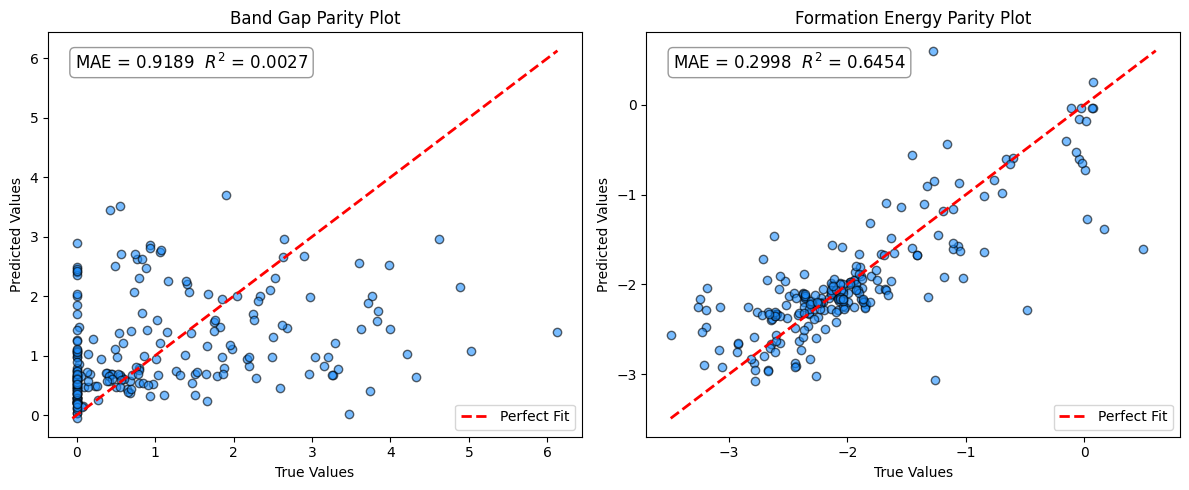

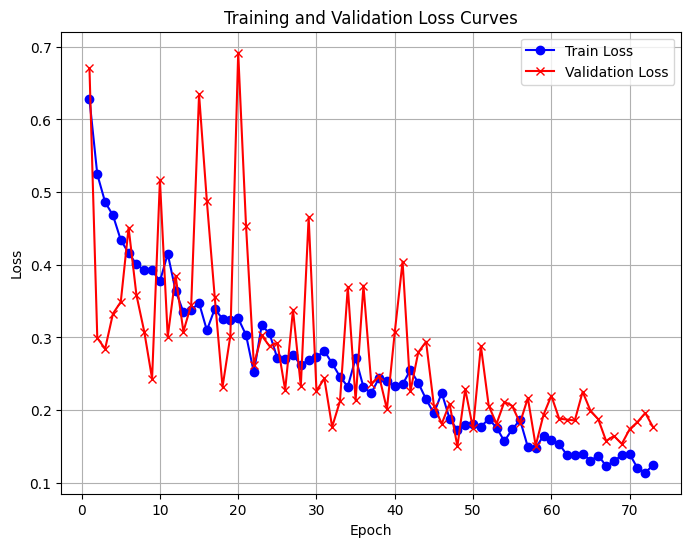

All tasks completed successfully!


In [ ]:
epochs = 100
batch_size = 32
num_samples = 1500
api_key = "Materials-Project-API"

pl.seed_everything(42)

if not api_key:
    raise ValueError("Materials Project API Key is required.")

print(f"Connecting to Materials Project using API Key: {api_key[:4]}...")
dataset = fetch_materials_project_data(api_key, num_samples)

metals = sum(1 for data in dataset if data.y[0, 0].item() == 0.0)
non_metals = len(dataset) - metals
print(f"[DATASET STATS] Total: {len(dataset)} | Metals: {metals} ({metals/len(dataset)*100:.1f}%) | Non-Metals: {non_metals} ({non_metals/len(dataset)*100:.1f}%)")

num_train = int(0.7 * len(dataset))
num_val = int(0.15 * len(dataset))

train_dataset = dataset[:num_train]
val_dataset = dataset[num_train:num_train+num_val]
test_dataset = dataset[num_train+num_val:]

train_loader = get_dataloader(train_dataset, batch_size=batch_size, is_train=True)
val_loader = get_dataloader(val_dataset, batch_size=batch_size, is_train=False)
test_loader = get_dataloader(test_dataset, batch_size=batch_size, is_train=False)

scaler = TargetScaler()
scaler.fit(train_loader)

print("Initializing PhysGNN-MTL model...")
model = PhysGNN_MTL(node_dim=10, edge_dim=3, n_qubits=4, scaler=scaler)


import shutil
if os.path.exists('checkpoints'):
    shutil.rmtree('checkpoints')
os.makedirs('checkpoints', exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints/',
    filename='best-model-{epoch:02d}-{val_loss:.2f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    save_last=True
)

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=25,
    mode='min'
)

trainer = pl.Trainer(
    max_epochs=epochs,
    accelerator='gpu',
    devices=1,
    callbacks=[checkpoint_callback, early_stop_callback],
    enable_progress_bar=True,
    log_every_n_steps=5,
    logger=False
)

print("Starting training pipeline...")
trainer.fit(model, train_loader, val_loader)

# Save training history BEFORE loading checkpoint (checkpoint creates a new object)
saved_train_losses = model.train_epoch_losses.copy()
saved_val_losses = model.val_epoch_losses.copy()

print("Loading best model for testing and plotting...")
best_model_path = checkpoint_callback.best_model_path
if best_model_path:
    model = PhysGNN_MTL.load_from_checkpoint(best_model_path, scaler=scaler)

# Restore training history onto the loaded model
model.train_epoch_losses = saved_train_losses
model.val_epoch_losses = saved_val_losses

# --- Inline Evaluation ---
model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(model.device)
        preds = model(batch)
        if model.scaler is not None:
            preds = model.scaler.inverse_transform(preds)
        all_preds.append(preds.cpu().numpy())
        all_trues.append(batch.y[:, :2].cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

properties = ['Band Gap', 'Formation Energy']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i in range(2):
    true_vals = all_trues[:, i]
    pred_vals = all_preds[:, i]
    mae = mean_absolute_error(true_vals, pred_vals)
    r2 = r2_score(true_vals, pred_vals)
    ax = axes[i]
    ax.scatter(true_vals, pred_vals, alpha=0.6, edgecolors='k', color='dodgerblue')
    min_val = min(true_vals.min(), pred_vals.min())
    max_val = max(true_vals.max(), pred_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    ax.set_title(f'{properties[i]} Parity Plot')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    textstr = f'MAE = {mae:.4f}  $R^2$ = {r2:.4f}'
    boxprops = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=boxprops)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

if len(model.train_epoch_losses) > 0 and len(model.val_epoch_losses) > 0:
    plt.figure(figsize=(8, 6))
    ep = range(1, len(model.train_epoch_losses) + 1)
    plt.plot(ep, model.train_epoch_losses, label='Train Loss', marker='o', color='blue')
    plt.plot(ep, model.val_epoch_losses, label='Validation Loss', marker='x', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

print("All tasks completed successfully!")


Loading best model for testing and plotting...


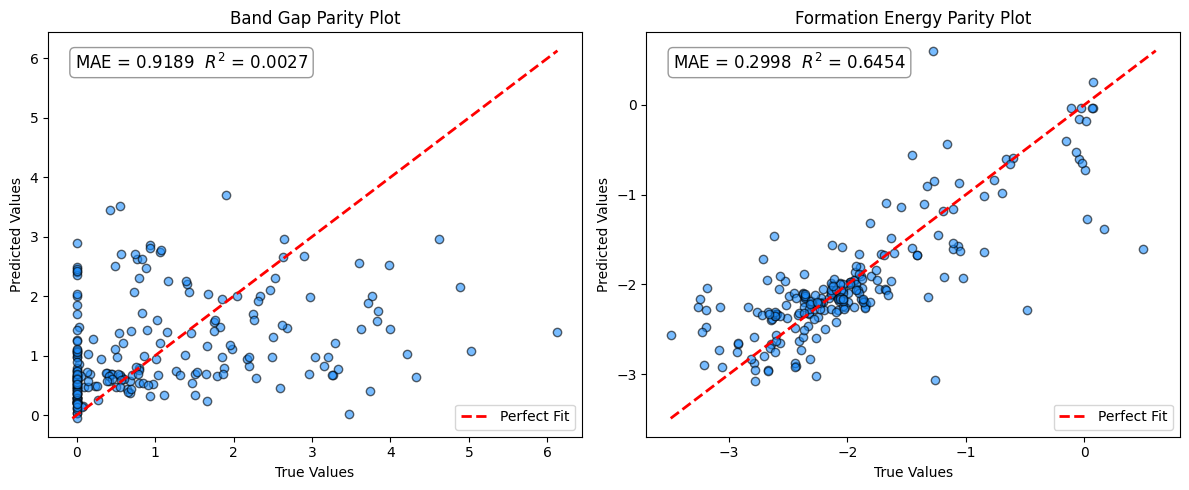

Evaluation complete!


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import torch
import os
# 1. Load the model from your new checkpoint
print("Loading best model for testing and plotting...")
best_model_path = checkpoint_callback.best_model_path
if best_model_path:
    model = PhysGNN_MTL.load_from_checkpoint(best_model_path, scaler=scaler)

# 2. Put model in evaluation mode
model.eval()

all_preds = []
all_trues = []

# 3. Gather predictions
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(model.device)
        
        preds = model(batch)
        
        if hasattr(model, 'scaler') and model.scaler is not None:
            preds = model.scaler.inverse_transform(preds)
            
        all_preds.append(preds.cpu().numpy())
        all_trues.append(batch.y.cpu().numpy())
        
all_preds = np.concatenate(all_preds, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

properties = ['Band Gap', 'Formation Energy']

# 4. Draw Parity Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    true_vals = all_trues[:, i]
    pred_vals = all_preds[:, i]
    
    mae = mean_absolute_error(true_vals, pred_vals)
    r2 = r2_score(true_vals, pred_vals)
    
    ax = axes[i]
    ax.scatter(true_vals, pred_vals, alpha=0.6, edgecolors='k', color='dodgerblue')
    
    min_val = min(true_vals.min(), pred_vals.min())
    max_val = max(true_vals.max(), pred_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    ax.set_title(f'{properties[i]} Parity Plot')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    
    textstr = f'MAE = {mae:.4f}  $R^2$ = {r2:.4f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    ax.legend(loc='lower right')
            
plt.tight_layout()
plt.show()

# 5. Draw Training Curves
if len(model.train_epoch_losses) > 0 and len(model.val_epoch_losses) > 0:
    plt.figure(figsize=(8, 6))
    epochs = range(1, len(model.train_epoch_losses) + 1)
    plt.plot(epochs, model.train_epoch_losses, label='Train Loss', marker='o', color='blue')
    plt.plot(epochs, model.val_epoch_losses, label='Validation Loss', marker='x', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

print("Evaluation complete!")
